# Nitrogen ($\mathrm{N_2}$) Purge Simulation for Hydrogen ($\mathrm{H_2}$) Line Maintenance

---

## <a id="table-of-contents"></a>Table of Contents
1. [<a id="toc-1"></a>Chemical Engineering & Safety Context](#sec-1)
   - [Hydrogen Flammability Envelope in Air](#sec-1-1)
   - [Fundamental Purging Dynamics](#sec-1-2)
   - [Physical Hazards Modeled in this Notebook](#sec-1-3)
2. [<a id="toc-2"></a>Thermodynamic Gas Models](#sec-2)
   - [Real Gas Equation of State for Nitrogen (`mp.N2`)](#sec-2-1)
   - [Ideal Gas Model for Hydrogen (`ig.H2`)](#sec-2-2)
3. [<a id="toc-3"></a>Pipeline Specifications & Purging Flow Dynamics](#sec-3)
   - [Mechanical & Process Parameters](#sec-3-1)
   - [Purge Supply & Volumetric Flow Conversion](#sec-3-2)
4. [<a id="toc-4"></a>Joule-Thomson Cooling Analysis & Numerical Perturbation](#sec-4)
   - [Thermodynamics of Isenthalpic Let-Down](#sec-4-1)
   - [Numerical Perturbation Method for Property Derivatives](#sec-4-2)
   - [Two-Stage Let-Down Thermal Profile](#sec-4-3)
5. [<a id="toc-5"></a>Purge Dilution Kinetics & Mixing Models](#sec-5)
   - [Mathematical Formulation of Non-Ideal Mixing](#sec-5-1)
   - [Required Volume Exchanges for Safe Ingress](#sec-5-2)
6. [<a id="toc-6"></a>Purge Time and Nitrogen Consumption](#sec-6)
   - [Mass Balance & Utility Inventory](#sec-6-1)
   - [Operational Sizing](#sec-6-2)
7. [<a id="toc-7"></a>Visualization & Performance Analysis](#sec-7)
   - [Figure 1: Joule-Thomson Coefficient ($\mu_{\mathrm{JT}}$) across Pressures](#fig-1)
   - [Figure 2: Temperature Drop Across Expansion Stages](#fig-2)
   - [Figure 3: Hydrogen Concentration Decay Kinetics](#fig-3)
   - [Figure 4: Purge Time and Nitrogen Consumption Sizing](#fig-4)
   - [Figure 5: Purge Duration Sensitivity Contour Map](#fig-5)
   - [Figure 6: Operational Safety Envelope & Hazard Classification](#fig-6)
8. [<a id="toc-8"></a>Engineering Recommendations & Operational Protocol](#sec-8)
   - [Recommended Industrial Purging Protocol](#sec-8-1)
   - [Material Integrity & JT Cooling Mitigation](#sec-8-2)

---

## <a id="sec-1"></a>1. Chemical Engineering & Safety Context

Before performing hot work (welding, cutting, grinding, or thermal line modifications) on a hydrogen pipeline, the residual combustible gas must be displaced by an inert gas—typically nitrogen ($\mathrm{N_2}$)—until the concentration is reduced well below the **Lower Explosive Limit (LEL)**.

### <a id="sec-1-1"></a>Hydrogen Flammability Envelope in Air

| Parameter / Flammability Threshold | Value (% vol) | Concentration (ppm) | Chemical Engineering Context |
| :--- | :---: | :---: | :--- |
| **Lower Explosive Limit (LEL)** | $4.0\%$ | $40,000\text{ ppm}$ | Minimum concentration in air capable of sustaining combustion |
| **Upper Explosive Limit (UEL)** | $75.0\%$ | $750,000\text{ ppm}$ | Maximum concentration in air for flame propagation |
| **Limiting Oxygen Concentration (LOC)** | $5.0\%\text{ }\mathrm{O_2}$ | $50,000\text{ ppm}$ | Minimum $\mathrm{O_2}$ required to support H₂ ignition |
| **Safe Limit for Hot Work** | $\le 0.5\%$ | $5,000\text{ ppm}$ | Industry standard safety threshold ($1/8$ of LEL or $<10\%$ of LEL) |
| **Initial Line Concentration ($C_0$)** | $100.0\%$ | $1,000,000\text{ ppm}$ | Undiluted hydrogen gas prior to maintenance purge |

- NFPA 86: Standard for Ovens and Furnaces (purge requirements)
- API 2009: Safe Welding, Cutting, and Hot Work Practices
- Perry's Chemical Engineers' Handbook, 9th Ed.: Section 27 — Safety
- PYroMat Handbook: Chapter 8 — Multi-Phase Model (mp1) for N₂ properties

### <a id="sec-1-2"></a>Fundamental Purging Dynamics

In an ideal, unmixed displacement process (plug flow), purging requires exactly 1 line volume of inert gas. However, in continuous displacement with mixing, concentration decay follows an exponential relationship:

$$C = C_0 \cdot e^{-N}$$

where $N$ is the number of purge line volumes exchanged. To dilute pure $\mathrm{H_2}$ ($100\%$) down to a safe working threshold ($0.4\% - 0.5\%$), the theoretical minimum purge volume is:

$$N = \ln\left(\frac{100.0}{0.4}\right) = \ln(250) \approx 5.52 \text{ line volumes}$$

As established in industrial safety guidelines (ref: [cv.ukhan.org/posts/h2_purge/](https://cv.ukhan.org/posts/h2_purge/)), standard field procedures mandate **7 to 10 line volume exchanges** to account for non-ideal mixing ($\eta < 1.0$), stagnant pockets, and dead-leg fittings.

### <a id="sec-1-3"></a>Physical Hazards Modeled in this Notebook

This simulation evaluates two critical physical phenomena:
1. **Joule-Thomson (JT) Isenthalpic Cooling**: Rapid expansion of $\mathrm{N_2}$ from high-pressure cylinders ($200\text{ bar}$) to line pressure ($1.5\text{ bar}$) causes severe temperature drops ($\Delta T \approx -30^\circ\mathrm{C}$). The resulting cold gas can cool carbon steel piping near or below its Minimum Design Metal Temperature (MDMT), inducing brittle fracture risks.
2. **Mixing Efficiency ($\eta$) Effects**: Real purge operations deviate from ideal plug flow and perfect CSTR mixing. We model dilution kinetics via $C = C_0 (1 - \eta)^N$ across realistic mixing efficiencies ($\eta = 0.3 - 1.0$).

### Environment Setup & Thermodynamic Unit Configuration

We begin by loading scientific computing libraries (`numpy`, `matplotlib`) and the **PYroMat** thermodynamic package. PYroMat unit settings are explicitly set to metric process engineering standards: `bar` for pressure, `K` for temperature, and `kJ` for specific enthalpy/energy.

In [1]:
import pyromat as pm
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Configure PYroMat thermodynamic units
pm.config['unit_pressure'] = 'bar'
pm.config['unit_temperature'] = 'K'
pm.config['unit_energy'] = 'kJ'

print("PYroMat environment initialized successfully:")
print(f"  Pressure unit:    {pm.config['unit_pressure']}")
print(f"  Temperature unit: {pm.config['unit_temperature']}")
print(f"  Energy unit:      {pm.config['unit_energy']}\n")

%reload_ext watermark
%watermark -v -m -p PYroMat,numpy,matplotlib

PYroMat environment initialized successfully:
  Pressure unit:    bar
  Temperature unit: K
  Energy unit:      kJ

Python implementation: CPython
Python version       : 3.11.2
IPython version      : 8.5.0

PYroMat   : 2.2.6
numpy     : 1.26.4
matplotlib: 3.10.9

Compiler    : GCC 12.2.0
OS          : Linux
Release     : 6.12.93+rpt-rpi-v8
Machine     : aarch64
Processor   : 
CPU cores   : 4
Architecture: 64bit



/home/ukhan/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## <a id="sec-2"></a>2. Thermodynamic Gas Models

To accurately capture fluid behavior, we employ distinct thermodynamic models for the inert purge gas ($\mathrm{N_2}$) and the displaced gas ($\mathrm{H_2}$).

### <a id="sec-2-1"></a>Real Gas Equation of State for Nitrogen (`mp.N2`)

Nitrogen at cylinder storage conditions ($200\text{ bar}$) exhibits significant real-gas deviations from the ideal gas law ($Z = \frac{p v}{R T} \neq 1$). We utilize PYroMat's **mp1 (multi-phase)** model, which implements the empirical Helmholtz free energy equation of state (Span–Wagner formulation):

$$\phi(\delta, \tau) = \phi^o(\delta, \tau) + \phi^r(\delta, \tau)$$

where $\delta = \rho/\rho_c$ is the reduced density and $\tau = T_c/T$ is the inverse reduced temperature. This real-gas formulation is crucial for:
- Calculating exact real-gas density $\rho_{\mathrm{N_2}}(T, p)$ across wide pressure drops.
- Evaluating the Joule-Thomson coefficient $\mu_{\mathrm{JT}} = \left(\frac{\partial T}{\partial p}\right)_h$, which is strictly **zero** for an ideal gas but positive ($\approx 0.2\text{ K/bar}$) for real $\mathrm{N_2}$ near ambient temperatures.

### <a id="sec-2-2"></a>Ideal Gas Model for Hydrogen (`ig.H2`)

Hydrogen is modeled using PYroMat's `ig.H2` class. Because the pipeline operates at low pressure ($1.5\text{ bar(a)}$) and hydrogen exhibits near-unity compressibility at ambient temperatures, the ideal gas EOS provides sufficient accuracy for mass balance and concentration decay calculations.

In [2]:
# Load substance models
n2 = pm.get('mp.N2')       # Real gas model — Helmholtz EOS for accurate JT & density
h2 = pm.get('ig.H2')       # Ideal gas model — adequate for low-pressure H2

print(f"Nitrogen substance model:  {n2.sid()}  (Class: {n2.data['class']})")
print(f"Hydrogen substance model:  {h2.sid()}  (Class: {h2.data['class']})")

Nitrogen substance model:  mp.N2  (Class: mp1)
Hydrogen substance model:  ig.H2  (Class: ig2)


## <a id="sec-3"></a>3. Pipeline Specifications & Purging Flow Dynamics

### <a id="sec-3-1"></a>Mechanical & Process Parameters

We model a standard industrial hydrogen transfer line in a chlor-alkali / petrochemical facility:
- **Nominal Diameter**: 6-inch Schedule 40 carbon steel pipe ($D_{\mathrm{inner}} = 0.15\text{ m}$).
- **Length**: $L = 50.0\text{ m}$.
- **Pipeline Volume**: $V_{\mathrm{line}} = \frac{\pi}{4} D_{\mathrm{inner}}^2 L = \frac{\pi}{4} (0.15)^2 (50) \approx 0.8836\,\mathrm{m^3} \quad (883.6\,\mathrm{L})$.
- **Initial State**: Pure hydrogen ($C_0 = 100.0\%$), line pressure $P_{\mathrm{line}} = 1.5\text{ bar(a)}$, ambient temperature $T_{\mathrm{line}} = 303.15\text{ K}$ ($30^\circ\mathrm{C}$).

### <a id="sec-3-2"></a>Purge Supply & Volumetric Flow Conversion

Purge gas is supplied at $50.0\,\mathrm{Nm^3/h}$ from a $200\text{ bar}$ cylinder manifold regulated down to $3.0\text{ bar(a)}$.

The normal flow rate $\dot{V}_{\mathrm{norm}}$ at $P_{\mathrm{norm}} = 1.01325\text{ bar}$, $T_{\mathrm{norm}} = 273.15\text{ K}$) is converted to actual volumetric flow rate $\dot{V}_{\mathrm{actual}}$ at pipeline conditions using the ideal gas relationship:

$$\dot{V}_{\mathrm{actual}} = \dot{V}_{\mathrm{norm}} \cdot \left(\frac{P_{\mathrm{norm}}}{P_{\mathrm{line}}}\right) \cdot \left(\frac{T_{\mathrm{line}}}{T_{\mathrm{norm}}}\right)$$

The time required to exchange one complete pipeline volume is:

$$t_{\mathrm{vol}} = \frac{V_{\mathrm{line}}}{\dot{V}_{\mathrm{actual}}}$$

In [3]:
# Hydrogen line specifications
LINE_LENGTH = 50.0          # m
LINE_DIAMETER = 0.15        # m  (6 inch Schedule 40)
LINE_VOLUME = np.pi * (LINE_DIAMETER/2)**2 * LINE_LENGTH   # m³
LINE_VOLUME_L = LINE_VOLUME * 1000                          # Litres
LINE_PRESSURE = 1.5          # bar(a) — typical H₂ supply pressure
LINE_TEMP = 303.15           # K (30 °C)

# Initial H₂ concentration & target safety limits
INITIAL_H2_PCT = 100.0       # % vol (pure H₂ initially)
TARGET_H2_PCT = 0.5          # % vol (target limit for welding/hot work)
LEL_H2 = 4.0                 # % vol (Lower Explosive Limit in air)
SAFE_MARGIN = 0.125          # 1/8 of LEL threshold

# Purge gas (N₂) supply parameters
N2_CYLINDER_PRESSURE = 200.0   # bar(a)
N2_REGULATOR_SET = 3.0         # bar(a)
N2_TEMPERATURE = 303.15        # K (30 °C)

# Purge flow rate parameters
PURGE_FLOW_NM3H = 50.0         # Nm³/h
P_NORM = 1.01325               # bar
T_NORM = 273.15                # K

# Convert Nm³/h to actual m³/s at line operating conditions
PURGE_FLOW_ACTUAL = (PURGE_FLOW_NM3H / 3600.0) * (P_NORM / LINE_PRESSURE) * (LINE_TEMP / T_NORM)
TIME_PER_VOLUME = LINE_VOLUME / PURGE_FLOW_ACTUAL   # seconds per exchange

# Mixing efficiencies to evaluate
MIXING_EFFICIENCIES = [0.3, 0.5, 0.7, 1.0]

print(f"Pipeline volume:          {LINE_VOLUME_L:.1f} L ({LINE_VOLUME:.4f} m³)")
print(f"Actual flow rate:         {PURGE_FLOW_ACTUAL:.4f} m³/s")
print(f"Time per volume exchange: {TIME_PER_VOLUME:.1f} s ({TIME_PER_VOLUME/60.0:.2f} min)")

Pipeline volume:          883.6 L (0.8836 m³)
Actual flow rate:         0.0104 m³/s
Time per volume exchange: 84.9 s (1.41 min)


## <a id="sec-4"></a>4. Joule-Thomson Cooling Analysis & Numerical Perturbation

### <a id="sec-4-1"></a>Thermodynamics of Isenthalpic Let-Down

When compressed nitrogen undergoes throttling across a pressure reduction valve (isenthalpic expansion, $\Delta h = 0$), its temperature change is governed by the Joule-Thomson coefficient $\mu_{\mathrm{JT}}$:

$$\mu_{\mathrm{JT}} \equiv \left(\frac{\partial T}{\partial p}\right)_h = -\frac{1}{c_p} \left(\frac{\partial h}{\partial p}\right)_T = \frac{1}{c_p} \left[ T \left(\frac{\partial v}{\partial T}\right)_p - v \right]$$

For an ideal gas, $T \left(\frac{\partial v}{\partial T}\right)_p = v$, rendering $\mu_{\mathrm{JT}} = 0$. For real nitrogen at ambient temperature, attractive intermolecular forces dominate during expansion, absorbing kinetic energy and producing a substantial cooling effect ($\mu_{\mathrm{JT}} > 0$).

### <a id="sec-4-2"></a>Numerical Perturbation Method for Property Derivatives

As discussed in [PYroMat Issue #71](https://github.com/chmartil/PYroMat/issues/71), PYroMat's thermodynamic state objects do not provide explicit analytical derivatives of enthalpy with respect to pressure. We compute $\left(\frac{\partial h}{\partial p}\right)_T$ using a central-difference numerical perturbation:

$$\left(\frac{\partial h}{\partial p}\right)_T \approx \frac{h(T, p + \varepsilon p) - h(T, p - \varepsilon p)}{2 \varepsilon p}$$

where $\varepsilon = 10^{-6}$ is a non-dimensional perturbation fraction. The Joule-Thomson coefficient is then evaluated as:

$$\mu_{\mathrm{JT}}(T, p) = -\frac{h(T, p + \varepsilon p) - h(T, p - \varepsilon p)}{2 \varepsilon p \cdot c_p(T, p)}$$

### <a id="sec-4-3"></a>Two-Stage Let-Down Thermal Profile

The pressure let-down occurs in two distinct stages:
1. **Stage 1 (Regulator)**: $200.0\text{ bar} \to 3.0\text{ bar}$
2. **Stage 2 (Line Let-Down)**: $3.0\text{ bar} \to 1.5\text{ bar}$

The final downstream temperature $T_2$ is solved directly by inverting the real-gas enthalpy relation using `mp.N2`:

$$h(T_2, p_2) = h(T_1, p_1)$$

In [4]:
def jt_coeff(substance, T, p):
    """Joule-Thomson coefficient via central-difference perturbation of enthalpy (K/bar)."""
    T_arr = np.atleast_1d(np.asarray(T, dtype=float))
    p_arr = np.atleast_1d(np.asarray(p, dtype=float))
    is_scalar = (np.ndim(T) == 0) and (np.ndim(p) == 0)

    EPS = 1e-6
    cp_list = []
    dh_dp_list = []

    for tt, pp in zip(T_arr.flat, p_arr.flat):
        cp_val = float(substance.cp(T=tt, p=pp))
        dp_val = EPS * pp
        h_p = float(substance.h(T=tt, p=pp + dp_val))
        h_m = float(substance.h(T=tt, p=pp - dp_val))
        dh_dp = (h_p - h_m) / (2.0 * dp_val)
        cp_list.append(cp_val)
        dh_dp_list.append(dh_dp)

    mu = -np.array(dh_dp_list) / np.array(cp_list)
    return float(mu[0]) if is_scalar else mu

def n2_temperature_after_expansion(T_in, p_in, p_out):
    """Temperature of N₂ after isenthalpic expansion from p_in to p_out."""
    h_in = float(n2.h(T=T_in, p=p_in))
    return float(n2.T(h=h_in, p=p_out))

# Compute temperatures after each expansion stage
T_after_reg = n2_temperature_after_expansion(N2_TEMPERATURE, N2_CYLINDER_PRESSURE, N2_REGULATOR_SET)
JT_drop_reg = N2_TEMPERATURE - T_after_reg

T_after_line = n2_temperature_after_expansion(T_after_reg, N2_REGULATOR_SET, LINE_PRESSURE)
JT_drop_line = T_after_reg - T_after_line

T_final_n2 = T_after_line
JT_drop_total = N2_TEMPERATURE - T_final_n2

# Scan JT coefficient over temperature range 250 K - 350 K at different pressures
T_scan = np.linspace(250, 350, 11)
mu_vs_T_200 = np.array([jt_coeff(n2, T, 200.0) for T in T_scan])
mu_vs_T_3   = np.array([jt_coeff(n2, T, N2_REGULATOR_SET) for T in T_scan])
mu_vs_T_1_5 = np.array([jt_coeff(n2, T, LINE_PRESSURE) for T in T_scan])

print(f"Initial N₂ Temperature:       {N2_TEMPERATURE - 273.15:.2f} °C  (200.0 bar)")
print(f"After Regulator (3.0 bar):     {T_after_reg - 273.15:.2f} °C  (ΔT = -{JT_drop_reg:.2f} °C)")
print(f"In Pipeline (1.5 bar):         {T_final_n2 - 273.15:.2f} °C  (Total ΔT = -{JT_drop_total:.2f} °C)")
print(f"μ_JT at 30°C, 200 bar:        {jt_coeff(n2, 303.15, 200.0):.4f} K/bar")
print(f"μ_JT at 30°C, 1.5 bar:         {jt_coeff(n2, 303.15, 1.5):.4f} K/bar")

Initial N₂ Temperature:       30.00 °C  (200.0 bar)
After Regulator (3.0 bar):     0.48 °C  (ΔT = -29.52 °C)
In Pipeline (1.5 bar):         0.09 °C  (Total ΔT = -29.91 °C)
μ_JT at 30°C, 200 bar:        0.0702 K/bar
μ_JT at 30°C, 1.5 bar:         0.2068 K/bar


## <a id="sec-5"></a>5. Purge Dilution Kinetics & Mixing Models

### <a id="sec-5-1"></a>Mathematical Formulation of Non-Ideal Mixing

During displacement purging, incoming nitrogen mixes with resident hydrogen. The concentration of residual hydrogen $C_N$ (% vol) after $N$ line volume exchanges is modeled as a geometric progression:

$$C_N = C_0 (1 - \eta)^N$$

where $\eta \in (0, 1]$ represents the effective volumetric mixing efficiency factor per volume exchange:

- **$\eta = 0.0$ (Plug Flow)**: Pure displacement front with zero mixing. Concentration remains $100\%$ until exactly $N = 1.0$ volume exchange, at which point $C \to 0\%$.
- **$\eta = 1.0$ (Perfect Mixing)**: Equivalent to a Continuous Stirred-Tank Reactor (CSTR). In continuous differential form:
  $$\frac{dC}{dN} = -C \implies C(N) = C_0 \cdot e^{-N}$$
- **$\eta = 0.3 - 0.7$ (Real Industrial Purging)**: Accounting for buoyancy stratification, velocity profiles, dead legs, and turbulent dispersion.

### <a id="sec-5-2"></a>Required Volume Exchanges for Safe Ingress

Solving for the required number of line volumes $N_{\mathrm{req}}$ to reach a target threshold $C_{\mathrm{target}} = 0.5\%$:

$$N_{\mathrm{req}} = \frac{\ln\left(\frac{C_{\mathrm{target}}}{C_0}\right)}{\ln(1 - \eta)} \quad (\text{for } 0 < \eta < 1)$$

For ideal mixing ($\eta = 1.0$), $N_{\mathrm{req}} = \ln\left(\frac{C_0}{C_{\mathrm{target}}}\right)$.

In [5]:
def h2_concentration_after_purge(N_volumes, efficiency=0.5):
    """H₂ concentration (% vol) after N purge volumes with mixing efficiency η."""
    return INITIAL_H2_PCT * (1.0 - efficiency) ** N_volumes

def purge_volumes_to_target(efficiency, target=TARGET_H2_PCT):
    """Number of line volumes required to reach target concentration."""
    if efficiency <= 0:
        return float('inf')
    if efficiency >= 1.0:
        return np.log(INITIAL_H2_PCT / target)
    return np.log(target / INITIAL_H2_PCT) / np.log(1.0 - efficiency)

N_max = 12
N_volumes = np.arange(0, N_max + 1)

decay_curves = {eta: h2_concentration_after_purge(N_volumes, eta) for eta in MIXING_EFFICIENCIES}
purge_vols_needed = {eta: purge_volumes_to_target(eta) for eta in MIXING_EFFICIENCIES}

print("Purge volumes required to reach ≤ 0.5% H₂:")
for eta in MIXING_EFFICIENCIES:
    print(f"  η = {eta:<3.1f}:  {purge_vols_needed[eta]:.2f} line volumes")

Purge volumes required to reach ≤ 0.5% H₂:
  η = 0.3:  14.85 line volumes
  η = 0.5:  7.64 line volumes
  η = 0.7:  4.40 line volumes
  η = 1.0:  5.30 line volumes


## <a id="sec-6"></a>6. Purge Time and Nitrogen Consumption

### <a id="sec-6-1"></a>Mass Balance & Utility Inventory

The total mass of nitrogen required per line volume exchange depends on real-gas density at pipeline conditions $\rho_{\mathrm{N_2}}(T_{\mathrm{final}}, P_{\mathrm{line}})$, computed using PYroMat's `mp.N2`:

$$
m_{\mathrm{vol}} = \rho_{\mathrm{N_2}} \cdot V_{\mathrm{line}}
$$

Total nitrogen consumption for $N_{\mathrm{req}}$ volume exchanges expressed in normal cubic metres ($\mathrm{Nm^3}$) at $P_{\mathrm{norm}} = 1.01325\,\mathrm{bar}$, $T_{\mathrm{norm}} = 273.15\,\mathrm{K}$ is:

$$
V_{\mathrm{Nm^3}} = \frac{N_{\mathrm{req}} \cdot m_{\mathrm{vol}}}{\rho_{\mathrm{norm}}}
$$

### <a id="sec-6-2"></a>Operational Sizing

Standard industrial $\mathrm{N_2}$ cylinders ($50\,\mathrm{L}$ water capacity at $200\,\mathrm{bar}$) contain approximately $10\,\mathrm{Nm^3}$ of usable gas. Evaluating required $\mathrm{Nm^3}$ allows plant engineers to specify cylinder bundle requirements prior to purging.


In [6]:
# N₂ density at line conditions and normal conditions
density_n2_line = float(n2.d(T=T_final_n2, p=LINE_PRESSURE))    # kg/m³
density_n2_norm = float(n2.d(T=T_NORM, p=P_NORM))            # kg/m³

mass_n2_per_volume = density_n2_line * LINE_VOLUME            # kg per line volume

purge_summary_data = []
for eta in MIXING_EFFICIENCIES:
    N_req = purge_vols_needed[eta]
    time_req_min = (N_req * TIME_PER_VOLUME) / 60.0    # minutes
    mass_req_kg = N_req * mass_n2_per_volume            # kg
    nm3_req = mass_req_kg / density_n2_norm             # Nm³
    
    purge_summary_data.append({
        'efficiency': eta,
        'volumes': N_req,
        'time_min': time_req_min,
        'mass_kg': mass_req_kg,
        'nm3': nm3_req
    })

print(f"{'η':<6} {'Volumes':<10} {'Time (min)':<12} {'N₂ (kg)':<10} {'N₂ (Nm³)':<10}")
print("-" * 50)
for d in purge_summary_data:
    print(f"{d['efficiency']:<6.1f} {d['volumes']:<10.2f} {d['time_min']:<12.2f} {d['mass_kg']:<10.2f} {d['nm3']:<10.2f}")

η      Volumes    Time (min)   N₂ (kg)    N₂ (Nm³)  
--------------------------------------------------
0.3    14.85      21.01        24.29      19.43     
0.5    7.64       10.81        12.50      10.00     
0.7    4.40       6.22         7.20       5.76      
1.0    5.30       7.49         8.66       6.93      


## <a id="sec-7"></a>7. Visualization & Performance Analysis

### <a id="fig-1"></a>Figure 1: Joule-Thomson Coefficient ($\mu_{\mathrm{JT}}$) across Pressures

The Joule-Thomson coefficient $\mu_{\mathrm{JT}} = \left(\frac{\partial T}{\partial p}\right)_h$ varies substantially with pressure and temperature:
- At **200 bar** (cylinder manifold), dense-gas repulsive forces reduce $\mu_{\mathrm{JT}}$ to $\approx 0.07\text{ K/bar}$.
- At **3 bar** and **1.5 bar** (line pressure), nitrogen approaches low-density behavior where attractive forces dominate, increasing $\mu_{\mathrm{JT}}$ to $\approx 0.20 - 0.21\text{ K/bar}$.

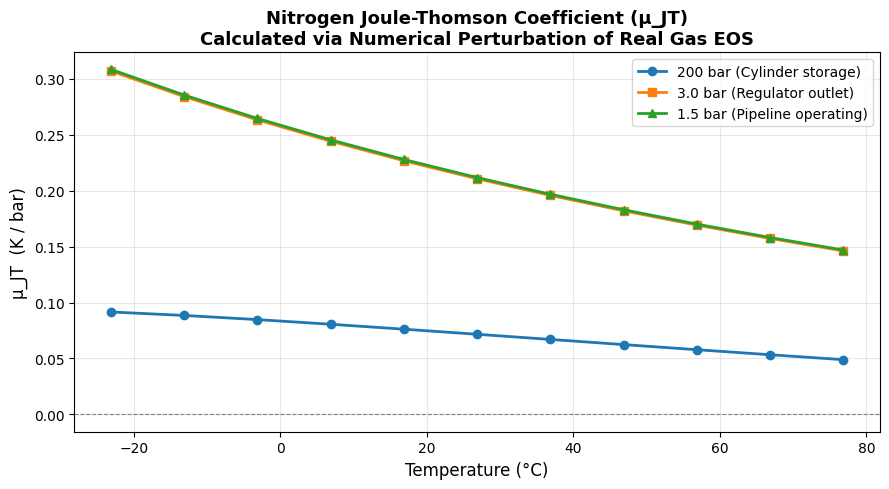

In [7]:
SAVE_DIR = '/home/ukhan/engg/ukhan/proj/pyromat_ukhan/'

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(T_scan - 273.15, mu_vs_T_200, 'o-', color='#1f77b4', linewidth=2,
        label='200 bar (Cylinder storage)')
ax.plot(T_scan - 273.15, mu_vs_T_3, 's-', color='#ff7f0e', linewidth=2,
        label=f'{N2_REGULATOR_SET:.1f} bar (Regulator outlet)')
ax.plot(T_scan - 273.15, mu_vs_T_1_5, '^-', color='#2ca02c', linewidth=2,
        label=f'{LINE_PRESSURE:.1f} bar (Pipeline operating)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('μ_JT  (K / bar)', fontsize=12)
ax.set_title('Nitrogen Joule-Thomson Coefficient (μ_JT)\n'
             'Calculated via Numerical Perturbation of Real Gas EOS',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig(SAVE_DIR + 'n2_purge_jt_coefficient.jpg', dpi=150)
plt.show()

### <a id="fig-2"></a>Figure 2: Temperature Drop Across Expansion Stages

This figure tracks the thermal history of nitrogen as it expands from $200\text{ bar}$ to line operating pressure ($1.5\text{ bar}$). The primary temperature drop ($\Delta T \approx -29.5^\circ\mathrm{C}$) occurs across the regulator stage ($200\text{ bar} \to 3\text{ bar}$), cooling the gas to near $0^\circ\mathrm{C}$.

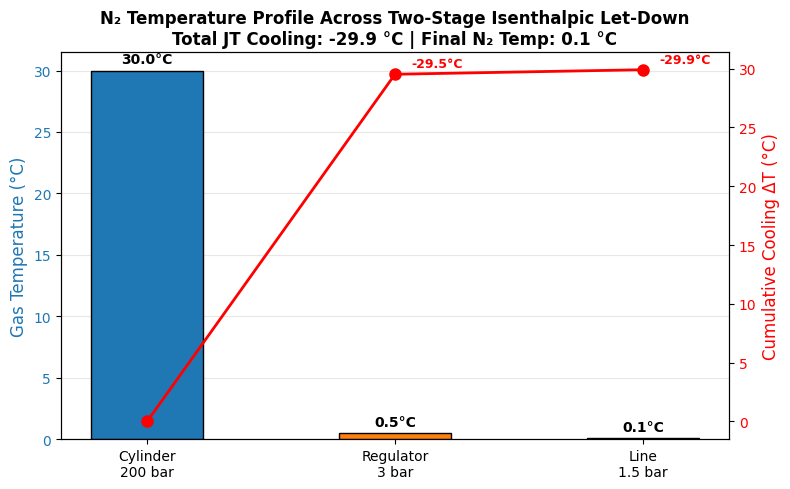

In [8]:
stages = ['Cylinder\n200 bar', 'Regulator\n3 bar', 'Line\n1.5 bar']
temps = [N2_TEMPERATURE - 273.15, T_after_reg - 273.15, T_final_n2 - 273.15]
drops = [0, JT_drop_reg, JT_drop_total]

fig, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(stages, temps, color=['#1f77b4', '#ff7f0e', '#2ca02c'],
               edgecolor='black', width=0.45, zorder=3)
ax1.set_ylabel('Gas Temperature (°C)', fontsize=12, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
for bar, val in zip(bars, temps):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
             f'{val:.1f}°C', ha='center', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(stages, drops, 'ro-', linewidth=2, markersize=8, zorder=4,
         label='Cumulative ΔT')
ax2.set_ylabel('Cumulative Cooling ΔT (°C)', fontsize=12, color='r')
ax2.tick_params(axis='y', labelcolor='r')
for i, d in enumerate(drops):
    if d != 0:
        ax2.annotate(f'-{d:.1f}°C', (stages[i], d),
                     textcoords='offset points', xytext=(12, 5),
                     fontsize=9, color='r', fontweight='bold')

ax1.set_title('N₂ Temperature Profile Across Two-Stage Isenthalpic Let-Down\n'
              f'Total JT Cooling: -{JT_drop_total:.1f} °C | Final N₂ Temp: {T_final_n2 - 273.15:.1f} °C',
              fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
#plt.savefig(SAVE_DIR + 'n2_purge_temperature_drop.jpg', dpi=150)
plt.show()

### <a id="fig-3"></a>Figure 3: Hydrogen Concentration Decay Kinetics

Semi-log representation of $\mathrm{H_2}$ concentration vs purge volume exchanges for mixing efficiencies $\eta \in [0.3, 1.0]$. Horizontal reference lines mark the LEL ($4.0\%$) and safe hot-work target ($0.5\%$).

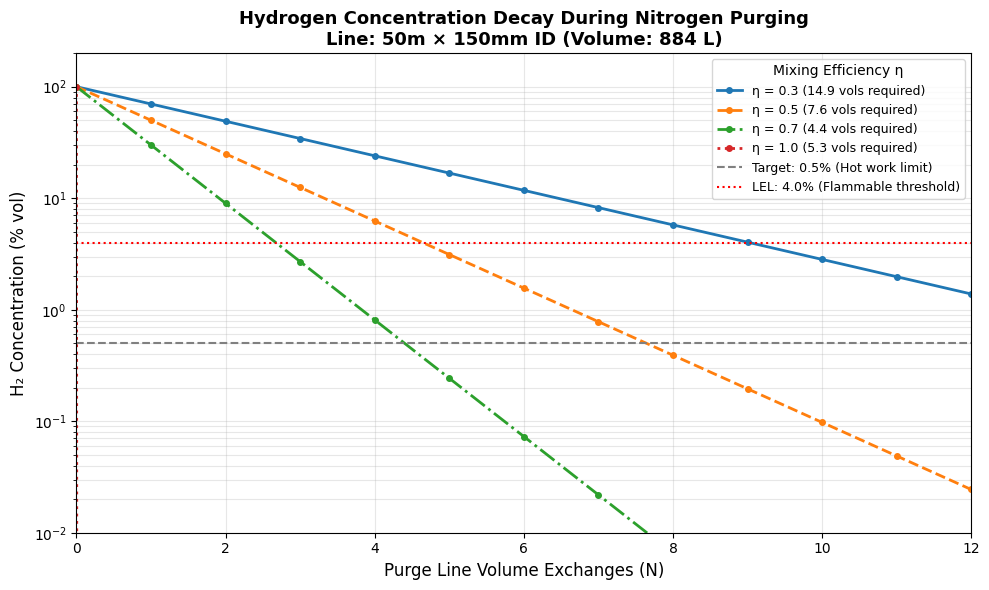

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_eta = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
line_styles = ['-', '--', '-.', ':']

for eta, c, ls in zip(MIXING_EFFICIENCIES, colors_eta, line_styles):
    ax.semilogy(N_volumes, decay_curves[eta], color=c, linestyle=ls,
                linewidth=2, marker='o', markersize=4,
                label=f'η = {eta} ({purge_vols_needed[eta]:.1f} vols required)')

ax.axhline(TARGET_H2_PCT, color='gray', linewidth=1.5, linestyle='--',
           label=f'Target: {TARGET_H2_PCT}% (Hot work limit)')
ax.axhline(LEL_H2, color='r', linewidth=1.5, linestyle=':',
           label=f'LEL: {LEL_H2}% (Flammable threshold)')

ax.set_xlabel('Purge Line Volume Exchanges (N)', fontsize=12)
ax.set_ylabel('H₂ Concentration (% vol)', fontsize=12)
ax.set_title('Hydrogen Concentration Decay During Nitrogen Purging\n'
             f'Line: 50m × 150mm ID (Volume: {LINE_VOLUME_L:.0f} L)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, title='Mixing Efficiency η')
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, N_max)
ax.set_ylim(0.01, 200)
plt.tight_layout()
#plt.savefig(SAVE_DIR + 'n2_purge_concentration_decay.jpg', dpi=150)
plt.show()

### <a id="fig-4"></a>Figure 4: Purge Time and Nitrogen Consumption Sizing

Comparison of total purging duration (minutes) and nitrogen volume consumed ($\text{Nm^3}$) required to achieve $\le 0.5\%\text{ H_2}$ across mixing efficiencies.

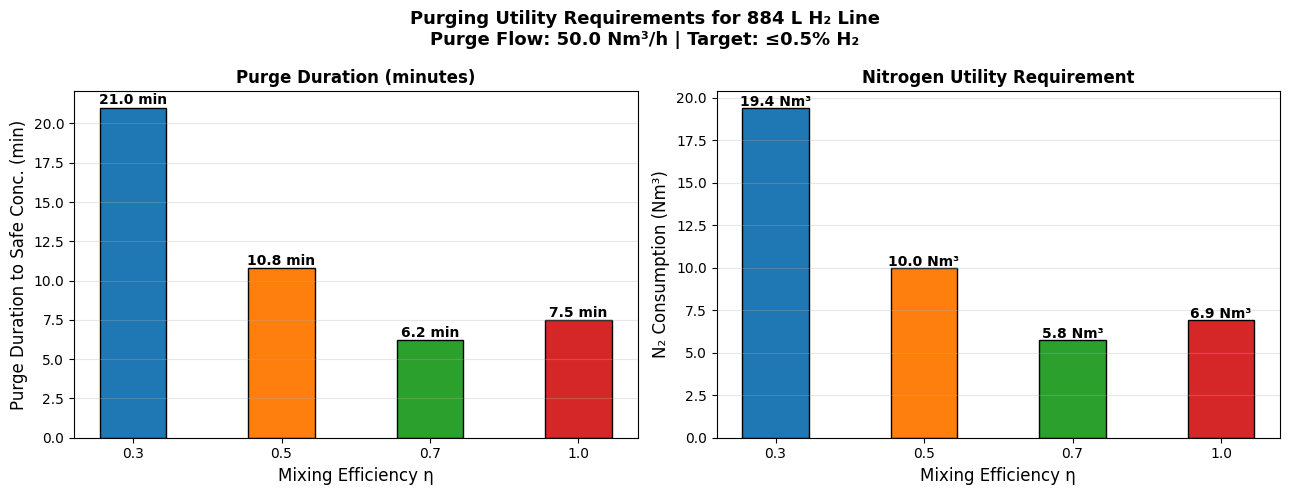

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

etas_plot = [d['efficiency'] for d in purge_summary_data]
times_plot = [d['time_min'] for d in purge_summary_data]
nm3_plot = [d['nm3'] for d in purge_summary_data]

bars1 = ax1.bar([str(e) for e in etas_plot], times_plot,
                color=colors_eta, edgecolor='black', width=0.45)
ax1.set_xlabel('Mixing Efficiency η', fontsize=12)
ax1.set_ylabel('Purge Duration to Safe Conc. (min)', fontsize=12)
ax1.set_title('Purge Duration (minutes)', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, times_plot):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f} min', ha='center', fontsize=10, fontweight='bold')
ax1.grid(True, axis='y', alpha=0.3)

bars2 = ax2.bar([str(e) for e in etas_plot], nm3_plot,
                color=colors_eta, edgecolor='black', width=0.45)
ax2.set_xlabel('Mixing Efficiency η', fontsize=12)
ax2.set_ylabel('N₂ Consumption (Nm³)', fontsize=12)
ax2.set_title('Nitrogen Utility Requirement', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, nm3_plot):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f} Nm³', ha='center', fontsize=10, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

fig.suptitle(f'Purging Utility Requirements for {LINE_VOLUME_L:.0f} L H₂ Line\n'
             f'Purge Flow: {PURGE_FLOW_NM3H} Nm³/h | Target: ≤{TARGET_H2_PCT}% H₂',
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig(SAVE_DIR + 'n2_purge_time_consumption.jpg', dpi=150)
plt.show()

### <a id="fig-5"></a>Figure 5: Purge Duration Sensitivity Contour Map

Parametric sensitivity map of purge time as a function of pipeline volume ($10 - 1000\text{ L}$) and mixing efficiency ($\eta = 0.2 - 1.0$) at $50\text{ Nm^3/h}$ purge rate.

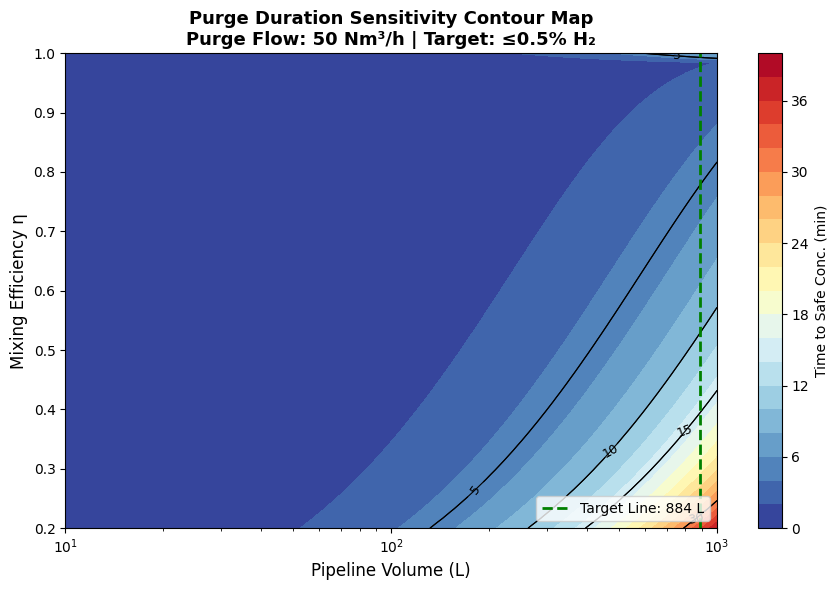

In [11]:
line_volumes = np.logspace(1, 3, 50)  # 10 to 1000 Litres
efficiencies = np.linspace(0.2, 1.0, 50)
V_grid, E_grid = np.meshgrid(line_volumes, efficiencies)

with np.errstate(divide='ignore'):
    N_req_grid = np.where(E_grid < 1.0,
                          np.log(TARGET_H2_PCT / INITIAL_H2_PCT) / np.log(1.0 - E_grid),
                          np.log(INITIAL_H2_PCT / TARGET_H2_PCT))

flow_actual_grid = (PURGE_FLOW_NM3H / 3600.0) * (P_NORM / LINE_PRESSURE) * (LINE_TEMP / T_NORM)
time_grid = N_req_grid * (V_grid / 1000.0) / flow_actual_grid / 60.0

fig, ax = plt.subplots(figsize=(9, 6))
contour = ax.contourf(V_grid, E_grid, time_grid, levels=20, cmap='RdYlBu_r')
cbar = plt.colorbar(contour, ax=ax, label='Time to Safe Conc. (min)')
ax.contour(V_grid, E_grid, time_grid, levels=[5, 10, 15, 30, 60],
           colors='k', linewidths=0.8)
ax.clabel(ax.contour(V_grid, E_grid, time_grid, levels=[5, 10, 15, 30, 60],
                      colors='k', linewidths=0.8), inline=True, fontsize=9)
ax.axvline(LINE_VOLUME_L, color='g', linewidth=2, linestyle='--',
           label=f'Target Line: {LINE_VOLUME_L:.0f} L')

ax.set_xlabel('Pipeline Volume (L)', fontsize=12)
ax.set_ylabel('Mixing Efficiency η', fontsize=12)
ax.set_title('Purge Duration Sensitivity Contour Map\n'
             'Purge Flow: 50 Nm³/h | Target: ≤0.5% H₂',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xscale('log')
plt.tight_layout()
#plt.savefig(SAVE_DIR + 'n2_purge_sensitivity.jpg', dpi=150)
plt.show()

### <a id="fig-6"></a>Figure 6: Operational Safety Envelope & Hazard Classification

Tri-zone safety classification envelope mapping purge progress:
- **Red Zone ($H_2 > 4.0\%$)**: Flammable / explosive regime. Hot work prohibited.
- **Yellow Zone ($0.5\% < H_2 \le 4.0\%$)**: Marginal region. Continuous monitoring required.
- **Green Zone ($H_2 \le 0.5\%$)**: Safe operating threshold for welding / hot work.

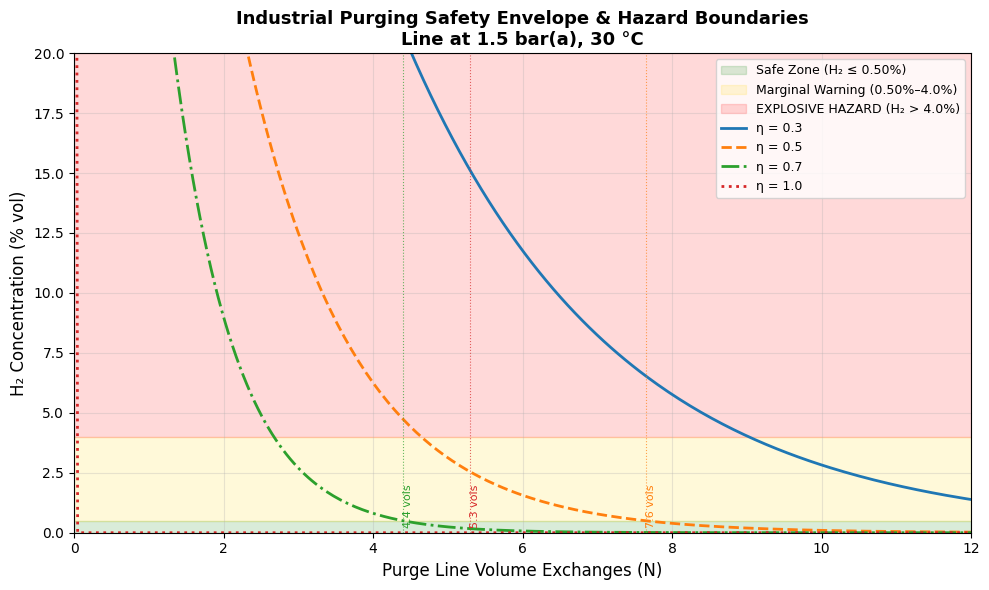

In [12]:
N_detailed = np.linspace(0, N_max, 250)
fig, ax = plt.subplots(figsize=(10, 6))

ax.axhspan(0, SAFE_MARGIN * LEL_H2, alpha=0.15, color='green',
           label=f'Safe Zone (H₂ ≤ {SAFE_MARGIN*LEL_H2:.2f}%)')
ax.axhspan(SAFE_MARGIN * LEL_H2, LEL_H2, alpha=0.15, color='gold',
           label=f'Marginal Warning ({SAFE_MARGIN*LEL_H2:.2f}%–{LEL_H2:.1f}%)')
ax.axhspan(LEL_H2, 20.0, alpha=0.15, color='red',
           label=f'EXPLOSIVE HAZARD (H₂ > {LEL_H2:.1f}%)')

for eta, c, ls in zip(MIXING_EFFICIENCIES, colors_eta, line_styles):
    conc = h2_concentration_after_purge(N_detailed, eta)
    ax.plot(N_detailed, conc, color=c, linestyle=ls, linewidth=2, label=f'η = {eta}')

for eta in MIXING_EFFICIENCIES:
    N_safe = purge_volumes_to_target(eta, SAFE_MARGIN * LEL_H2)
    if np.isfinite(N_safe) and N_safe <= N_max:
        ax.axvline(N_safe, color=colors_eta[MIXING_EFFICIENCIES.index(eta)],
                   linewidth=0.8, linestyle=':', alpha=0.7)
        ax.annotate(f'{N_safe:.1f} vols', (N_safe, 0.2),
                    fontsize=8, color=colors_eta[MIXING_EFFICIENCIES.index(eta)],
                    rotation=90, va='bottom')

ax.set_xlabel('Purge Line Volume Exchanges (N)', fontsize=12)
ax.set_ylabel('H₂ Concentration (% vol)', fontsize=12)
ax.set_title('Industrial Purging Safety Envelope & Hazard Boundaries\n'
             'Line at 1.5 bar(a), 30 °C',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 20)
ax.set_xlim(0, N_max)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig(SAVE_DIR + 'n2_purge_safety_envelope.jpg', dpi=150)
plt.show()

## <a id="sec-8"></a>8. Engineering Recommendations & Operational Protocol

### <a id="sec-8-1"></a>Recommended Industrial Purging Protocol

| Phase | Action | Process Detail |
| :--- | :--- | :--- |
| **1. Isolation** | Line Lockout | Close and tag double-block-and-bleed valves at both line battery limits. |
| **2. Depressurization** | Atmospheric Vent | Open elevated vent stack to reduce pressure to atmospheric ($1.0\text{ bar(a)}$). |
| **3. Utility Connection** | Regulated Supply | Connect $\mathrm{N_2}$ manifold at injection point with pre-heater or staged regulator. |
| **4. Purge Execution** | Flow Control | Maintain velocity $> 5\text{ m/s}$ to ensure turbulent mixing ($\eta \approx 0.7$). Purge minimum **4.5 to 7.0 line volumes**. |
| **5. Verification** | Atmospheric Testing | Sample vent gas with calibrated electrochemical / thermal conductivity $\mathrm{H_2}$ meter until $C_{\mathrm{H_2}} \le 0.5\%$. |
| **6. Maintenance** | Positive Pressure | Maintain $0.1 - 0.2\text{ bar}$ positive $\mathrm{N_2}$ purge pad during hot work to prevent air ingress. |

### <a id="sec-8-2"></a>Material Integrity & JT Cooling Mitigation

- **MDMT Concern**: Uncontrolled let-down yields $\mathrm{N_2}$ at $-0.1^\circ\mathrm{C}$ to $-29.5^\circ\mathrm{C}$. Verify line material spec against Minimum Design Metal Temperature (MDMT for standard A106 Gr B carbon steel without impact testing is $-29^\circ\mathrm{C}$).
- **Mitigation**: Use an inline electric or steam heater upstream of the regulator during high-flow purging.

In [13]:
print("=" * 65)
print("  N₂ PURGE SIMULATION — HYDROGEN LINE INERTING SUMMARY")
print("=" * 65)

print(f"\nLINE SPECIFICATIONS")
print(f"  Length:              {LINE_LENGTH:.0f} m")
print(f"  Diameter:            {LINE_DIAMETER*1000:.0f} mm  ({LINE_DIAMETER*39.37:.1f} in)")
print(f"  Volume:              {LINE_VOLUME_L:.0f} L  ({LINE_VOLUME:.3f} m³)")
print(f"  Operating Pressure:  {LINE_PRESSURE:.1f} bar(a)")
print(f"  Temperature:         {LINE_TEMP-273.15:.0f} °C")

print(f"\nJOULE-THOMSON COOLING (200 → 1.5 bar)")
print(f"  After Regulator:     {T_after_reg-273.15:.1f} °C  (ΔT = -{JT_drop_reg:.1f} °C)")
print(f"  In Pipeline:         {T_final_n2-273.15:.1f} °C  (Total ΔT = -{JT_drop_total:.1f} °C)")
print(f"  μ_JT at 30°C:        {jt_coeff(n2, 303.15, 200.0):.4f} K/bar (200 bar)")
print(f"                       {jt_coeff(n2, 303.15, 1.5):.4f} K/bar (1.5 bar)")

print(f"\nPURGE FLOW & UTILITIES")
print(f"  Normal Flow Rate:    {PURGE_FLOW_NM3H} Nm³/h")
print(f"  Actual Flow Rate:    {PURGE_FLOW_ACTUAL:.4f} m³/s  ({PURGE_FLOW_ACTUAL*1000:.1f} L/s)")
print(f"  Time per Volume:     {TIME_PER_VOLUME:.1f} s")
print(f"  N₂ Density in Line:  {density_n2_line:.3f} kg/m³")

print(f"\nDILUTION SUMMARY TO ≤ {TARGET_H2_PCT}% H₂")
print(f"  {'η':<6} {'Volumes':<10} {'Time(min)':<10} {'N₂(kg)':<10} {'N₂(Nm³)':<10} Status")
print(f"  {'-'*55}")
for d in purge_summary_data:
    status = '✓ Feasible' if d['volumes'] < 20 else '✗ Inefficient'
    print(f"  {d['efficiency']:<6.1f} {d['volumes']:<10.1f} {d['time_min']:<10.1f} "
          f"{d['mass_kg']:<10.2f} {d['nm3']:<10.1f} {status}")

best_purge = purge_summary_data[2]  # η = 0.7
print(f"\nRECOMMENDED OPERATING POINT (η = 0.7)")
print(f"  • Recommended Purge:  {best_purge['volumes']:.1f} line volumes")
print(f"  • Expected Duration:  {best_purge['time_min']:.1f} minutes")
print(f"  • N₂ Requirement:     {best_purge['nm3']:.1f} Nm³ (~1 cylinder bundle)")
print("  • Verification:       Portable electrochemical H₂ detector at vent")
print(f"  • Temperature Note:   Gas enters line at {T_final_n2-273.15:.1f}°C. Verify MDMT of piping.")

  N₂ PURGE SIMULATION — HYDROGEN LINE INERTING SUMMARY

LINE SPECIFICATIONS
  Length:              50 m
  Diameter:            150 mm  (5.9 in)
  Volume:              884 L  (0.884 m³)
  Operating Pressure:  1.5 bar(a)
  Temperature:         30 °C

JOULE-THOMSON COOLING (200 → 1.5 bar)
  After Regulator:     0.5 °C  (ΔT = -29.5 °C)
  In Pipeline:         0.1 °C  (Total ΔT = -29.9 °C)
  μ_JT at 30°C:        0.0702 K/bar (200 bar)
                       0.2068 K/bar (1.5 bar)

PURGE FLOW & UTILITIES
  Normal Flow Rate:    50.0 Nm³/h
  Actual Flow Rate:    0.0104 m³/s  (10.4 L/s)
  Time per Volume:     84.9 s
  N₂ Density in Line:  1.851 kg/m³

DILUTION SUMMARY TO ≤ 0.5% H₂
  η      Volumes    Time(min)  N₂(kg)     N₂(Nm³)    Status
  -------------------------------------------------------
  0.3    14.9       21.0       24.29      19.4       ✓ Feasible
  0.5    7.6        10.8       12.50      10.0       ✓ Feasible
  0.7    4.4        6.2        7.20       5.8        ✓ Feasible
  1.0    5